# Analysis Notebook

## Data Loading

In [ ]:
import pandas as pd
import sweetviz as sv

def explore (Data):
    print(Data.head(5))
    print(Data.info())
    M_Values = Data.isnull().sum().sort_values(ascending=False) 
    print(M_Values)
    print(Data.duplicated().sum())
    missing = M_Values.index[0]
    print(Data[Data[missing].isnull()])


tpl_BGI_2023 = pd.read_csv("data/tpl-branch-general-information-2023.csv",index_col=0)
tpl_BSR_2024 = pd.read_csv("data/tpl-branch-space-rentals-2024.csv",index_col=0)
tpl_RABB = pd.read_csv("data/tpl-card-registrations-annual-by-branch.csv",index_col=0)
tpl_EFS2 = pd.read_csv("data/tpl-events-feed_source2.csv",index_col=0)
# tpl_EFS1 = pd.read_csv("data/tpl-events-feed.csv",index_col=0) the two are exactly the same
tpl_VABB = pd.read_csv("data/tpl-visits-annual-by-branch.csv",index_col=0)
tpl_WUABB_2018_2023 = pd.read_csv("data/tpl-workstation-usage-annual-by-branch-2018-2023.csv",index_col=0)
tpl_LCBCT = pd.read_csv("data/library-circulation-by-cardholder-type.csv",index_col=0)

print("Table tpl-branch-general-information-2023 info:\n")
explore(tpl_BGI_2023)

print("\n --------------------------------------------------------\n")


print("Table tpl-branch-space-rentals-2024 info:\n")
explore(tpl_BSR_2024)

print("\n --------------------------------------------------------\n")

print("Table tpl-card-registrations-annual-by-branch info:\n")
explore(tpl_RABB)

print("\n --------------------------------------------------------\n")

print("Table tpl-events-feed_source2 info:\n")
explore(tpl_EFS2)

print("\n --------------------------------------------------------\n")

print("Table tpl-visits-annual-by-branch info:\n")
explore(tpl_VABB)

print("\n --------------------------------------------------------\n")


print("Table tpl-workstation-usage-annual-by-branch-2018-2023 info:\n")
explore(tpl_WUABB_2018_2023)

print("\n --------------------------------------------------------\n")


print("Table library-circulation-by-cardholder-type info:\n")
explore(tpl_LCBCT)

print("\n --------------------------------------------------------\n")


# # print(tpl_BSR_2024.describe())
# # tpl_BSR_2024_SV = sv.analyze(tpl_BSR_2024)
# # tpl_BSR_2024_SV.show_html()



Table tpl-branch-general-information-2023 info:

    BranchCode  PhysicalBranch       BranchName  \
_id                                               
1           AB               1           Albion   
2          ACD               1  Albert Campbell   
3           AD               1        Alderwood   
4           AG               1        Agincourt   
5           AH               1   Armour Heights   

                                       Address PostalCode  \
_id                                                         
1       1515 Albion Road, Toronto, ON, M9V 1B2    M9V 1B2   
2    496 Birchmount Road, Toronto, ON, M1K 1N8    M1K 1N8   
3        2 Orianna Drive, Toronto, ON, M8W 4Y1    M8W 4Y1   
4       155 Bonis Avenue, Toronto, ON, M1T 3W6    M1T 3W6   
5       2140 Avenue Road, Toronto, ON, M5M 4M7    M5M 4M7   

                               Website     Telephone SquareFootage  \
_id                                                                  
1            https://www.

### Initial exploration

In [4]:
tpl_BGI_2023 = pd.read_csv("data/tpl-branch-general-information-2023.csv",index_col=0)

In [5]:
tpl_BGI_2023.info()

<class 'pandas.DataFrame'>
RangeIndex: 112 entries, 1 to 112
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   BranchCode            112 non-null    str    
 1   PhysicalBranch        112 non-null    int64  
 2   BranchName            112 non-null    str    
 3   Address               103 non-null    str    
 4   PostalCode            103 non-null    str    
 5   Website               108 non-null    str    
 6   Telephone             105 non-null    str    
 7   SquareFootage         110 non-null    str    
 8   PublicParking         100 non-null    str    
 9   KidsStop              100 non-null    float64
 10  LeadingReading        100 non-null    float64
 11  CLC                   100 non-null    float64
 12  DIH                   100 non-null    float64
 13  TeenCouncil           100 non-null    float64
 14  YouthHub              100 non-null    float64
 15  AdultLiteracyProgram  100 non-null

In [6]:
print(tpl_BGI_2023["TPLNIA"])
tpl_BGI_2023['CLC'].unique()

_id
1      1.0
2      1.0
3      0.0
4      0.0
5      0.0
      ... 
108    1.0
109    0.0
110    0.0
111    0.0
112    1.0
Name: TPLNIA, Length: 112, dtype: float64


array([ 1.,  0., nan])

In [7]:
# Table tpl-branch-general-information-2023 clean:


def clean_branches(df):
    # remove all non physical branches
    # df = df[df['PhysicalBranch'] == 1] - this is to remove rows
    df =  df[df['KidsStop'].notnull()]
    drop_columns = [
    # Location
    'Address',
    'PostalCode',
    'Lat',
    'Long',
    'WardName',
    'NBHDNo',
    'WardNo',
    # Program Indicators
    'AdultLiteracyProgram',
    'LeadingReading',
    # Operational
    'SquareFootage',
    'PublicParking',
    'Website',
    'Telephone',
    'ServiceTier',
    'PresentSiteYear']
    df = df.drop(columns = drop_columns)
    return df

tpl_BGI_2023_cl = clean_branches(tpl_BGI_2023)
print(tpl_BGI_2023_cl.head(5))
print(tpl_BGI_2023_cl.info()) 
print(tpl_BGI_2023_cl['PhysicalBranch'].sum())

# branch_names = set(tpl_BGI_2023_cl['BranchName'].unique())
tpl_BGI_2023_cl['BranchName'].unique()

tpl_BGI_2023_cl['BranchName'] = tpl_BGI_2023_cl['BranchName'].str.replace(
    'Jane/Dundas', 'Daniel G. Hill'
)

branch_names = set(tpl_BGI_2023_cl['BranchName'].unique())



    BranchCode  PhysicalBranch       BranchName  KidsStop  CLC  DIH  \
_id                                                                   
1           AB               1           Albion       1.0  1.0  1.0   
2          ACD               1  Albert Campbell       0.0  1.0  1.0   
3           AD               1        Alderwood       0.0  0.0  0.0   
4           AG               1        Agincourt       0.0  1.0  1.0   
5           AH               1   Armour Heights       0.0  0.0  0.0   

     TeenCouncil  YouthHub  Workstations                           NBHDName  \
_id                                                                           
1            1.0       1.0          38.0  Mount Olive-Silverstone-Jamestown   
2            1.0       1.0          36.0               Clairlea-Birchmount    
3            0.0       0.0           7.0                          Alderwood   
4            0.0       1.0          42.0            Tam O'Shanter-Sullivan    
5            0.0       0.0  

In [8]:
tpl_BGI_2023_cl[tpl_BGI_2023_cl['BranchName'] == 'Online']



,BranchCode,PhysicalBranch,BranchName,KidsStop,CLC,DIH,TeenCouncil,YouthHub,Workstations,NBHDName,TPLNIA
_id,,,,,,,,,,,


In [9]:
# Table tpl-branch-space-rentals-2024 cleaning:

def clean_branches(df):
    # remove all non physical branches
    df = df[df['Square footage'].notnull()]
    drop_columns = [
        'Name',
        'Square footage'
    ]
    df = df.drop(columns = drop_columns)
    return df

tpl_BSR_2024_cl = clean_branches(tpl_BSR_2024)
print(tpl_BSR_2024_cl.head(5))
print(tpl_BSR_2024_cl.info())
print(tpl_BSR_2024_cl.Type.unique())
tpl_BSR_2024_cl.groupby(by = ['Branch Code', 'Type']).sum()

                Type  MaxCapacity Branch Code
_id                                          
1    Community Rooms         60.0          AB
2    Community Rooms         12.0          AB
3    Community Rooms         95.0         ACD
4    Community Rooms         25.0         ACD
5    Community Rooms         65.0          AG
<class 'pandas.DataFrame'>
Index: 124 entries, 1 to 162
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Type         124 non-null    str    
 1   MaxCapacity  123 non-null    float64
 2   Branch Code  124 non-null    str    
dtypes: float64(1), str(2)
memory usage: 3.9 KB
None
<StringArray>
['Community Rooms', 'Theatres', 'Venue', 'Program Room']
Length: 4, dtype: str


,,MaxCapacity
Branch Code,Type,
AB,Community Rooms,72.0
ACD,Community Rooms,120.0
AG,Community Rooms,65.0
AN,Community Rooms,65.0
BB,Community Rooms,55.0
...,...,...
WS,Community Rooms,55.0
WY,Community Rooms,59.0
YO,Community Rooms,16.0


In [10]:
# Table tpl-card-registrations-annual-by-branch cleaning:

print(tpl_RABB.groupby(['BranchCode', 'Year']).sum())

# def clean_branches(df):
#     # remove all non physical branches
#     df = df[df[''].notnull()]
#     drop_columns = [
#         'Name',
#         'Square footage'
#     ]
#     df = df.drop(columns = drop_columns)
#     return df

# tpl_RABB_cl = clean_branches(tpl_RABB)
# print(tpl_RABB_cl.head(5))
# print(tpl_RABB_cl.info())

                 Registrations
BranchCode Year               
AB         2012           4939
           2013           4483
           2014           3810
           2015           4272
           2016           4474
...                        ...
YW         2019           2773
           2020            396
           2021            415
           2022           1116
           2023           2828

[1275 rows x 1 columns]


In [11]:
# Table tpl-events-feed_source2 clean 

print(tpl_EFS2['LastUpdatedOn'].unique())

def clean_branches(df):
    # remove all non physical branches
    # df = df[df[''].notnull()]
    drop_columns = [
        'EventID',
        'StartTime',
        'EndTime',
        'StartDateLocal',
        'RegistrationClosed',
        'FeaturedImageUrl'
    ]
    df = df.drop(columns = drop_columns)
    df = df[~df['LocationName'].str.contains('Junction', case=True)]
    return df

tpl_EFS2_cl = clean_branches(tpl_EFS2)
print(tpl_EFS2_cl.head(5))
print(tpl_EFS2_cl.info())


tpl_EFS2_cl['LocationName'] = tpl_EFS2_cl['LocationName'].str.replace("Dufferin/St.Clair", "Dufferin/St. Clair")

tpl_EFS2_cl[tpl_EFS2_cl['LocationName'].isnull()]
events_locations = set(tpl_EFS2_cl['LocationName'].unique())

# events_Aud = set(tpl_EFS2_cl['Audiences'].unique())


print("Matching:", len(events_locations & branch_names))
print("Not matching:", events_locations - branch_names)

tpl_EFS2_cl[tpl_EFS2_cl['LocationName'].isnull()]


<StringArray>
['2026-02-26T12:22:14']
Length: 1, dtype: str
                                                 Title  \
_id                                                      
1                                  Tea & Entertainment   
2                                  Tea & Entertainment   
3                     D&D for Teens: On-going Campaign   
4                     S. Walter Stewart Seniors Social   
5    Finding Recovery Through Exercise Skills and H...   

                   LocationName                   Audiences Languages  \
_id                                                                     
1    North York Central Library  Adults (18+), Older Adults   English   
2    North York Central Library  Adults (18+), Older Adults   English   
3             S. Walter Stewart               Teens (13-17)   English   
4             S. Walter Stewart                Older Adults   English   
5             Parliament Street                Adults (18+)   English   

                     

,Title,LocationName,Audiences,Languages,EventTypes,IsRecurring,IsFull,Status,RegistrationIsFull,LastUpdatedOn
_id,,,,,,,,,,
234,Novel Novels Book Club,NaN,Adults (18+),English,Book Clubs & Writers Groups,True,False,ACTIVE,False,2026-02-26T12:22:14
235,Novel Novels Book Club,NaN,Adults (18+),English,Book Clubs & Writers Groups,True,False,ACTIVE,False,2026-02-26T12:22:14
236,Novel Novels Book Club,NaN,Adults (18+),English,Book Clubs & Writers Groups,True,False,ACTIVE,False,2026-02-26T12:22:14
1168,Google AI Essentials: Online Learning Circle,NaN,Adults (18+),English,Artificial Intelligence,True,True,ACTIVE,True,2026-02-26T12:22:14
1172,Women in Skateboarding: A History of Girl Gang...,NaN,Adults (18+),English,"Author Talks & Lectures, Culture, Arts & Enter...",False,False,ACTIVE,NaN,2026-02-26T12:22:14
...,...,...,...,...,...,...,...,...,...,...
7797,Book Layouts with Adobe InDesign,NaN,"Adults (18+), Older Adults, Younger Adults (18...",English,Audio & Visual,False,False,ACTIVE,NaN,2026-02-26T12:22:14
7798,Vector Design with Affinity,NaN,"Adults (18+), Older Adults, Younger Adults (18...",English,Audio & Visual,False,False,ACTIVE,NaN,2026-02-26T12:22:14
7806,Loïe Fuller et Isadora Duncan renouvellent l’a...,NaN,Adults (18+),French,"Culture, Arts & Entertainment",False,False,ACTIVE,NaN,2026-02-26T12:22:14


In [12]:
events_Aud = set(tpl_EFS2_cl['Audiences'].unique())
len(events_Aud)

33

In [13]:
# Table tpl-visits-annual-by-branch clean 

print(tpl_VABB.info())

df_visits_agg = tpl_VABB.groupby('BranchCode')['Visits'].sum()

print(df_visits_agg)


<class 'pandas.DataFrame'>
RangeIndex: 1233 entries, 1 to 1233
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Year        1233 non-null   int64
 1   BranchCode  1233 non-null   str  
 2   Visits      1233 non-null   int64
dtypes: int64(2), str(1)
memory usage: 29.0 KB
None
BranchCode
AB     3269625
ACD    2446043
AD      944173
AG     3512745
AH      614425
        ...   
WP      482728
WS     3888933
WY      964600
YO     1528481
YW     1828917
Name: Visits, Length: 104, dtype: int64


In [14]:
tpl_WUABB_2018_2023.info()
tpl_WUABB_2018_2023.head(5)
tpl_WUABB_2018_2023_AGG = tpl_WUABB_2018_2023.groupby(['BranchCode','Year']).sum()
print(tpl_WUABB_2018_2023_AGG)

<class 'pandas.DataFrame'>
RangeIndex: 592 entries, 1 to 592
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Year        592 non-null    int64
 1   BranchCode  592 non-null    str  
 2   Sessions    592 non-null    int64
dtypes: int64(2), str(1)
memory usage: 14.0 KB
                 Sessions
BranchCode Year          
AB         2018    111939
           2019    105936
           2020     26076
           2021     14154
           2022     44967
...                   ...
YW         2019     62065
           2020      8832
           2021      3571
           2022     16088
           2023     19605

[592 rows x 1 columns]


In [15]:

tpl_LCBCT.info()
tpl_LCBCT.head(5)
tpl_LCBCT.CardholderType.unique()
tpl_LCBCT_AGG = tpl_LCBCT.groupby(['BranchCode', 'CardholderType', 'Year']).sum()
print(tpl_LCBCT_AGG)

<class 'pandas.DataFrame'>
RangeIndex: 675 entries, 1 to 675
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Year            675 non-null    int64
 1   BranchCode      675 non-null    str  
 2   CardholderType  675 non-null    str  
 3   Circulation     675 non-null    int64
dtypes: int64(2), str(2)
memory usage: 21.2 KB
                                Circulation
BranchCode CardholderType Year             
AB         Adult          2022       154235
                          2023       115744
           Child          2022        43244
                          2023        35228
           Teen           2022        12313
...                                     ...
YW         Adult          2023        35246
           Child          2022         6216
                          2023         8000
           Teen           2022         1714
                          2023         2258

[675 rows x 1 columns]


In [16]:
# merging my main table with the event table:

merged_data = tpl_BGI_2023_cl.merge(
    tpl_EFS2_cl,
    left_on='BranchName',      # column name in left table
    right_on='LocationName',     # column name in right table
    how='right'           # join type
)

merged_data.info()
merged_data.head(5)
merged_data.Audiences.unique()           


<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BranchCode          8437 non-null   str    
 1   PhysicalBranch      8437 non-null   float64
 2   BranchName          8437 non-null   str    
 3   KidsStop            8437 non-null   float64
 4   CLC                 8437 non-null   float64
 5   DIH                 8437 non-null   float64
 6   TeenCouncil         8437 non-null   float64
 7   YouthHub            8437 non-null   float64
 8   Workstations        8437 non-null   float64
 9   NBHDName            8437 non-null   str    
 10  TPLNIA              8437 non-null   float64
 11  Title               8500 non-null   str    
 12  LocationName        8437 non-null   str    
 13  Audiences           8500 non-null   str    
 14  Languages           8500 non-null   str    
 15  EventTypes          8500 non-null   str    
 16  IsRecurring      

<StringArray>
[                                                                                             'Adults (18+), Older Adults',
                                                                                                           'Teens (13-17)',
                                                                                                            'Older Adults',
                                                                                                            'Adults (18+)',
                                                                                                'Preschool Children (0-5)',
                                                                                              'School Age Children (6-12)',
                                                                      'Adults (18+), Older Adults, Younger Adults (18-24)',
                                                                    'Preschool Children (0-5), School Age Children (6-

In [17]:
# working with merged table

# Step 1: Creating columns
merged_data['IsChildren'] = merged_data['Audiences'].str.contains('Children')
merged_data['IsTeens'] = merged_data['Audiences'].str.contains('Teens')
merged_data['IsAdults'] = merged_data['Audiences'].str.contains('Adults')

# Step 2: Group by brench and sum:

events_by_group = merged_data.groupby('BranchName')[
    ['IsChildren', 'IsTeens', 'IsAdults']
].sum()

# Online events - all NaN location rows from events table

online_events = tpl_EFS2_cl[tpl_EFS2_cl['LocationName'].isnull()].copy()
online_events['LocationName'] = 'Online'

online_events['IsChildren'] = online_events['Audiences'].str.contains('Children')
online_events['IsTeens'] = online_events['Audiences'].str.contains('Teens')
online_events['IsAdults'] = online_events['Audiences'].str.contains('Adults')


events_by_group_online = online_events.groupby('LocationName')[
    ['IsChildren', 'IsTeens', 'IsAdults']
].sum()

events_by_group_online = events_by_group_online.rename_axis('BranchName')

events_by_group
events_by_group_online

EBB_final = pd.concat([events_by_group, events_by_group_online])


EBB_final

,IsChildren,IsTeens,IsAdults
BranchName,,,
Agincourt,40,21,57
Albert Campbell,53,11,60
Albion,60,26,19
Alderwood,20,0,2
Amesbury Park,67,3,32
...,...,...,...
Woodview Park,118,4,68
Wychwood,34,1,11
York Woods,69,40,76


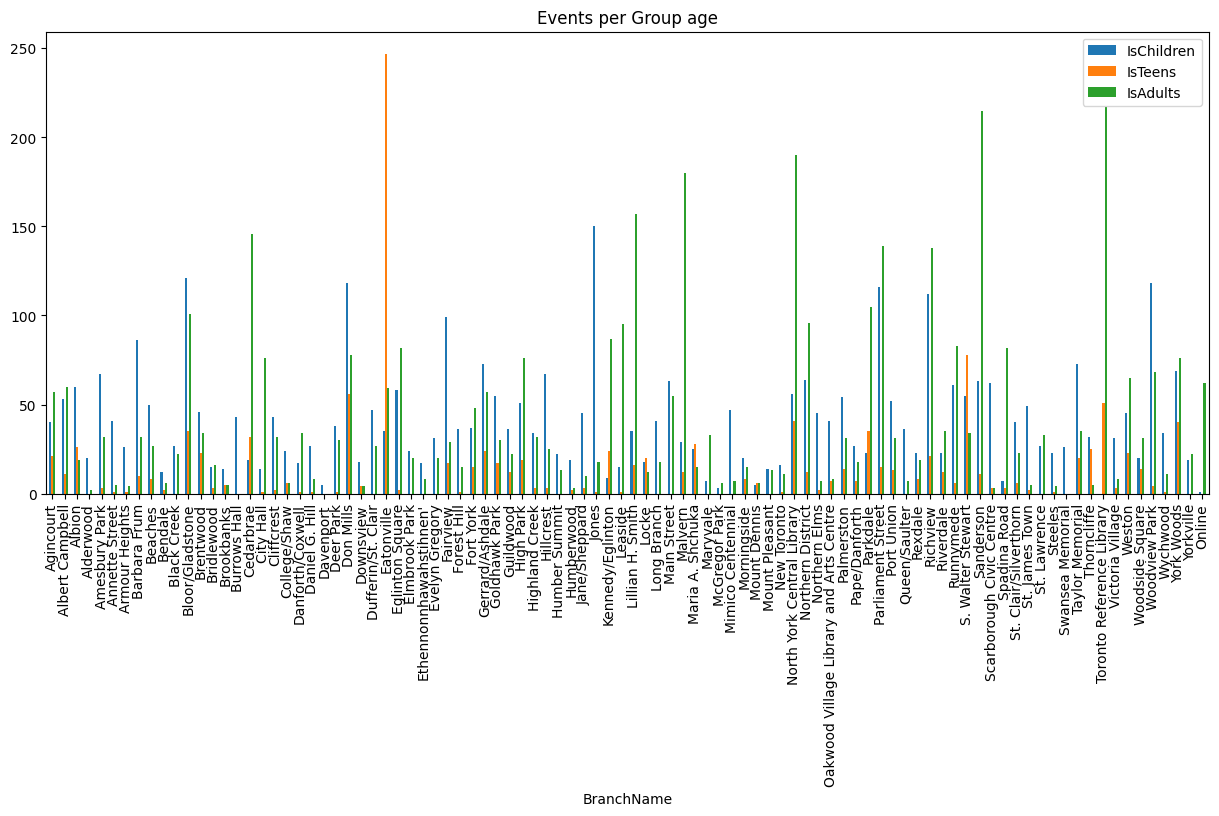

In [18]:
# Step 3 creating the histogram graph
# this graph will show all combined into one chart

import matplotlib.pyplot as plt




EBB_final[['IsChildren', 'IsTeens', 'IsAdults']].plot(
    kind='bar',
    alpha= 1,
    figsize=(15, 6)
)

plt.title('Events per Group age')
# plt.xlabel('Events Count')
# plt.ylabel('Participants (Targeted for the specific age)')
plt.show()

                            IsChildren  IsTeens  IsAdults  Total
BranchName                                                      
Eatonville                          35      247        59    341
Sanderson                           63       11       215    289
North York Central Library          56       41       190    287
Richview                           112       21       138    271
Parliament Street                  116       15       139    270
Toronto Reference Library            0       51       217    268
Bloor/Gladstone                    121       35       101    257
Don Mills                          118       56        78    252
Malvern                             29       12       180    221
Lillian H. Smith                    35       16       157    208
Cedarbrae                           19       32       146    197
Woodview Park                      118        4        68    190
York Woods                          69       40        76    185
Northern District        

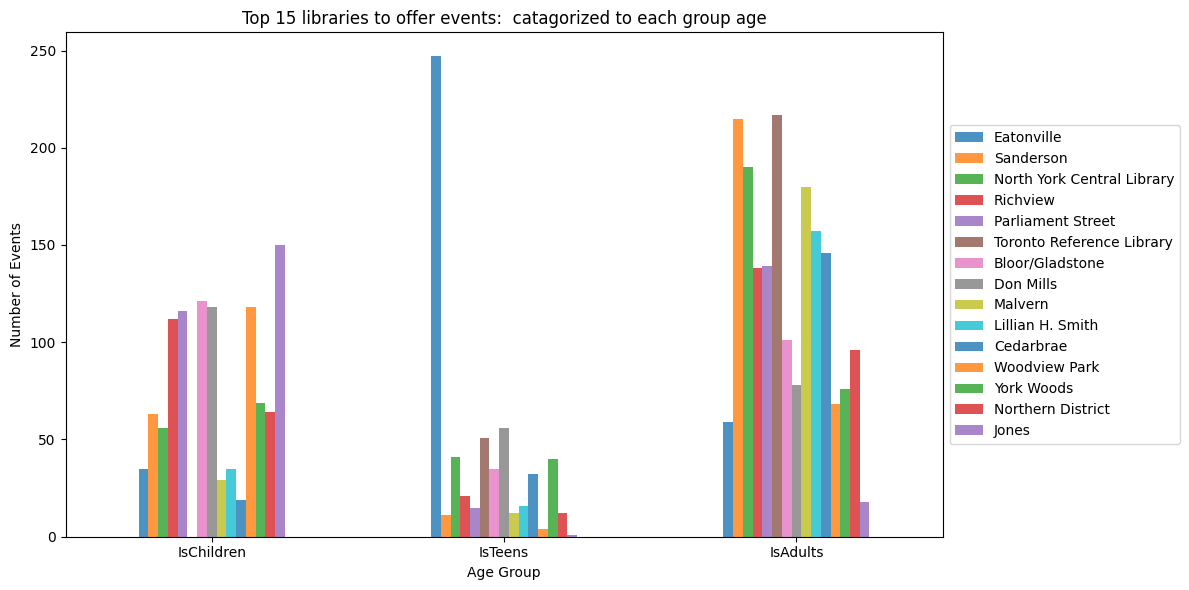

,IsChildren,IsTeens,IsAdults,Total
BranchName,,,,
Agincourt,40,21,57,118
Albert Campbell,53,11,60,124
Albion,60,26,19,105
Alderwood,20,0,2,22
Amesbury Park,67,3,32,102
...,...,...,...,...
Woodview Park,118,4,68,190
Wychwood,34,1,11,46
York Woods,69,40,76,185


In [34]:
# Another version (1.2) - Taking top 15 only

EBB_final['Total'] = EBB_final['IsChildren'] + \
                     EBB_final['IsTeens'] + \
                     EBB_final['IsAdults']


# Get top 15 and lowest 15
top15 = EBB_final.nlargest(15, 'Total')
low15 = EBB_final.nsmallest(15, 'Total')

print(top15.sort_values(by = 'Total', ascending=False))

# Drop total column after filtering
top15 = top15.drop(columns='Total')
low15 = low15.drop(columns='Total')

top15.T.plot(
    kind='bar',
    figsize=(12, 6),
    alpha=0.8
)

plt.title('Top 15 libraries to offer events:  catagorized to each group age')
plt.xlabel('Age Group')
plt.ylabel('Number of Events')
plt.xticks(rotation=0)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)
plt.tight_layout()
# print(top15.BrenchName.sum())
# print(top15.sort_values(by = 'BrenchName', ascending=False))
plt.show()
EBB_final